# 🤖 CoreTech Client Inquiry — Text Classification
**Internship Project | NLP Task**

This notebook trains a text classification model on client inquiry messages for CoreTech, categorizing them into:
- Web Development
- App Development
- UI/UX Design
- Digital Marketing
- SEO
- Software Solutions
- General Inquiry
- Complaint

**Models Used:** Naive Bayes & Logistic Regression  
**Vectorization:** TF-IDF

## 📦 Step 1: Install & Import Libraries

In [3]:
# Install required libraries (already available in Colab, just ensuring)
!pip install -q scikit-learn pandas matplotlib seaborn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

In [5]:
# ---------------------------------------------------------------
# Option A: Load from Google Drive (recommended)
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/coretech_client_inquiries.csv')

# ---------------------------------------------------------------
# Option B: Upload directly (uncomment below)
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('coretech_client_inquiries.csv')

# ---------------------------------------------------------------
# Option C: Load from GitHub raw URL (if you push the CSV first)
# url = 'https://raw.githubusercontent.com/YOUR_USERNAME/YOUR_REPO/main/coretech_client_inquiries.csv'
# df = pd.read_csv(url)

# ---------------------------------------------------------------
# DEFAULT: Build dataset inline (no file needed)
data = {
    'message': [
        # Web Development
        "I need a professional website for my restaurant business with online ordering features.",
        "Can you build me an e-commerce site where customers can buy my handmade products?",
        "We need a corporate website redesign for our law firm with a modern look.",
        "I want a portfolio website to showcase my photography work.",
        "Our company needs a custom CMS so we can update content ourselves.",
        "Can you create a landing page for our new product launch?",
        "We need a real estate website with property listings and a search filter.",
        "I want a blog website with categories, tags, and a newsletter signup.",
        "Build us a membership website where users can log in and access exclusive content.",
        "We need a multi-language website for our international business.",
        # App Development
        "I need an iOS and Android app for my food delivery startup.",
        "Can you develop a fitness tracking app with GPS and calorie counter?",
        "We want to build a social networking app similar to Instagram for our niche community.",
        "I need a mobile app for my salon to allow customers to book appointments.",
        "Can you create a meditation and mental wellness app with guided sessions?",
        "We need a cross-platform app for managing field sales teams.",
        "I want an augmented reality app for my furniture store so customers can visualize products.",
        "Build us a ride-sharing app with real-time driver tracking.",
        "We need a learning management app for our school with quizzes and video lessons.",
        "Can you develop a hospital patient management mobile app?",
        # UI/UX Design
        "Our app looks outdated, we need a complete UI redesign to improve user experience.",
        "We want a user research study and wireframes before we start building our product.",
        "Can you create high-fidelity prototypes for our SaaS dashboard?",
        "We need a design system with reusable components for our development team.",
        "Our checkout flow has a high drop-off rate, can you audit and improve the UX?",
        "I need a complete brand identity with logo, color palette, and typography guidelines.",
        "Can you design user journey maps and personas for our e-commerce platform?",
        "We need accessibility improvements across our web application for WCAG compliance.",
        "Design a mobile-first interface for our banking app with a clean and trustworthy feel.",
        "We want usability testing and a report on pain points in our current product.",
        # Digital Marketing
        "We need help running Google Ads and Facebook campaigns for our clothing brand.",
        "Can you manage our social media accounts and create engaging content?",
        "We want to launch an influencer marketing campaign for our skincare products.",
        "Help us with email marketing automation to nurture our leads.",
        "We need a comprehensive content marketing strategy for the next 6 months.",
        "Can you run retargeting ads to bring back visitors who didn't convert on our site?",
        "We want to grow our YouTube channel and need video content strategy.",
        "Help us set up and optimize our Google My Business profile.",
        "We need a paid media strategy to launch our new subscription service.",
        "Can you help with affiliate marketing setup for our online store?",
        # SEO
        "Our website is not ranking on Google. We need full SEO services.",
        "Can you do keyword research and on-page optimization for our blog?",
        "We need technical SEO audit and fixes for our e-commerce store.",
        "Help us with local SEO so our business appears in local search results.",
        "Our organic traffic dropped after a Google update, can you help us recover?",
        "We need backlink building and off-page SEO for our new website.",
        "Can you optimize our product pages for better search visibility?",
        "We need SEO competitor analysis to understand why rivals rank higher than us.",
        "Help us create an SEO content calendar targeting high-volume keywords.",
        "We want a monthly SEO reporting dashboard with rank tracking.",
        # Software Solutions
        "We need custom ERP software to manage our manufacturing operations.",
        "Can you build a CRM system tailored to our real estate agency?",
        "We need an inventory management system integrated with our POS.",
        "Build us an HR and payroll software for our 200-employee company.",
        "We need a custom billing and invoicing system for our accounting firm.",
        "Can you develop an API integration between our warehouse and shipping systems?",
        "We need a data analytics dashboard to track KPIs across our business units.",
        "Build a document management system with role-based access for our hospital.",
        "We need automation software to reduce manual data entry in our operations.",
        "Can you help migrate our legacy system to a modern cloud-based solution?",
        # General Inquiry
        "Hello, I just wanted to know what services your company offers.",
        "What is your pricing for a basic website project?",
        "Do you offer monthly maintenance packages for existing websites?",
        "I would like to schedule a discovery call to discuss my project.",
        "How long does it usually take to complete a mobile app project?",
        "Do you work with international clients?",
        "Can you share some case studies or examples of your previous work?",
        "What technologies and platforms do you specialize in?",
        "Do you offer any free consultation before starting a project?",
        "I am a student, do you offer any discounted packages for startups?",
        # Complaint
        "I am very unhappy with the website you delivered. It doesn't match what we agreed on.",
        "The mobile app has multiple bugs that were supposed to be fixed weeks ago.",
        "Your team has been very unresponsive and we have missed our launch deadline.",
        "I paid for SEO services 3 months ago and my rankings have not improved at all.",
        "The design you delivered looks nothing like the approved mockup.",
        "We are experiencing constant downtime on our website and no one is helping us.",
        "Your support team took 5 days to respond to a critical server issue.",
        "I feel cheated. The final product has fewer features than what was promised.",
        "The invoices I keep receiving do not match the contract we signed.",
        "We had a very bad experience with your project manager who was rude and dismissive.",
    ],
    'category': (
        ['Web Development'] * 10 +
        ['App Development'] * 10 +
        ['UI/UX Design'] * 10 +
        ['Digital Marketing'] * 10 +
        ['SEO'] * 10 +
        ['Software Solutions'] * 10 +
        ['General Inquiry'] * 10 +
        ['Complaint'] * 10
    )
}

df = pd.DataFrame(data)
print(f'✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(10)

✅ Dataset loaded: 80 rows, 2 columns


,message,category
0,I need a professional website for my restauran...,Web Development
1,Can you build me an e-commerce site where cust...,Web Development
2,We need a corporate website redesign for our l...,Web Development
3,I want a portfolio website to showcase my phot...,Web Development
4,Our company needs a custom CMS so we can updat...,Web Development
5,Can you create a landing page for our new prod...,Web Development
6,We need a real estate website with property li...,Web Development
7,"I want a blog website with categories, tags, a...",Web Development
8,Build us a membership website where users can ...,Web Development
9,We need a multi-language website for our inter...,Web Development


## 📊 Step 3: Exploratory Data Analysis (EDA)

In [6]:
print('=== Dataset Info ===')
print(df.info())
print('\n=== Category Distribution ===')
print(df['category'].value_counts())
print('\n=== Missing Values ===')
print(df.isnull().sum())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   message   80 non-null     object
 1   category  80 non-null     object
dtypes: object(2)
memory usage: 1.4+ KB
None

=== Category Distribution ===
category
Web Development       10
App Development       10
UI/UX Design          10
Digital Marketing     10
SEO                   10
Software Solutions    10
General Inquiry       10
Complaint             10
Name: count, dtype: int64

=== Missing Values ===
message     0
category    0
dtype: int64


In [ ]:
# Category distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

category_counts = df['category'].value_counts()

# Bar chart
colors = ['#4F81BD', '#C0504D', '#9BBB59', '#8064A2', '#4BACC6', '#F79646', '#2C4770', '#E06C75']
axes[0].bar(category_counts.index, category_counts.values, color=colors)
axes[0].set_title('Client Inquiry Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Messages')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(category_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Category Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved as category_distribution.png')

In [ ]:
# Message length analysis
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print('=== Message Length Stats ===')
print(df[['message_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['message_length'], bins=20, color='#4BACC6', edgecolor='black')
axes[0].set_title('Distribution of Message Lengths (chars)')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['word_count'], bins=20, color='#9BBB59', edgecolor='black')
axes[1].set_title('Distribution of Word Counts')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## ✂️ Step 4: Train-Test Split

In [7]:
X = df['message']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')
print(f'\nTest set category distribution:')
print(y_test.value_counts())

Training samples : 64
Testing  samples : 16

Test set category distribution:
category
SEO                   2
App Development       2
Complaint             2
General Inquiry       2
Software Solutions    2
Digital Marketing     2
UI/UX Design          2
Web Development       2
Name: count, dtype: int64


## 🔠 Step 5: TF-IDF Vectorization

In [8]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words='english',
    lowercase=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')
print(f'Total features             : {len(tfidf.get_feature_names_out())}')

TF-IDF matrix shape (train): (64, 500)
TF-IDF matrix shape (test) : (16, 500)
Total features             : 500


## 🧠 Step 6: Train Model 1 — Naive Bayes

In [9]:
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print('=' * 55)
print('       NAIVE BAYES — RESULTS')
print('=' * 55)
print(f'\n✅ Accuracy: {nb_accuracy * 100:.2f}%\n')
print('Classification Report:')
print('-' * 55)
print(classification_report(y_test, y_pred_nb))

       NAIVE BAYES — RESULTS

✅ Accuracy: 43.75%

Classification Report:
-------------------------------------------------------
                    precision    recall  f1-score   support

   App Development       0.50      0.50      0.50         2
         Complaint       0.00      0.00      0.00         2
 Digital Marketing       0.50      0.50      0.50         2
   General Inquiry       1.00      0.50      0.67         2
               SEO       0.50      0.50      0.50         2
Software Solutions       1.00      0.50      0.67         2
      UI/UX Design       0.33      0.50      0.40         2
   Web Development       0.25      0.50      0.33         2

          accuracy                           0.44        16
         macro avg       0.51      0.44      0.45        16
      weighted avg       0.51      0.44      0.45        16



## 🧠 Step 7: Train Model 2 — Logistic Regression

In [10]:
lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver='lbfgs',
    multi_class='auto',
    random_state=42
)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print('=' * 55)
print('       LOGISTIC REGRESSION — RESULTS')
print('=' * 55)
print(f'\n✅ Accuracy: {lr_accuracy * 100:.2f}%\n')
print('Classification Report:')
print('-' * 55)
print(classification_report(y_test, y_pred_lr))

       LOGISTIC REGRESSION — RESULTS

✅ Accuracy: 62.50%

Classification Report:
-------------------------------------------------------
                    precision    recall  f1-score   support

   App Development       0.67      1.00      0.80         2
         Complaint       1.00      0.50      0.67         2
 Digital Marketing       0.50      0.50      0.50         2
   General Inquiry       1.00      0.50      0.67         2
               SEO       0.67      1.00      0.80         2
Software Solutions       1.00      0.50      0.67         2
      UI/UX Design       0.50      0.50      0.50         2
   Web Development       0.33      0.50      0.40         2

          accuracy                           0.62        16
         macro avg       0.71      0.62      0.62        16
      weighted avg       0.71      0.62      0.62        16



## 📊 Step 8: Confusion Matrix Visualization

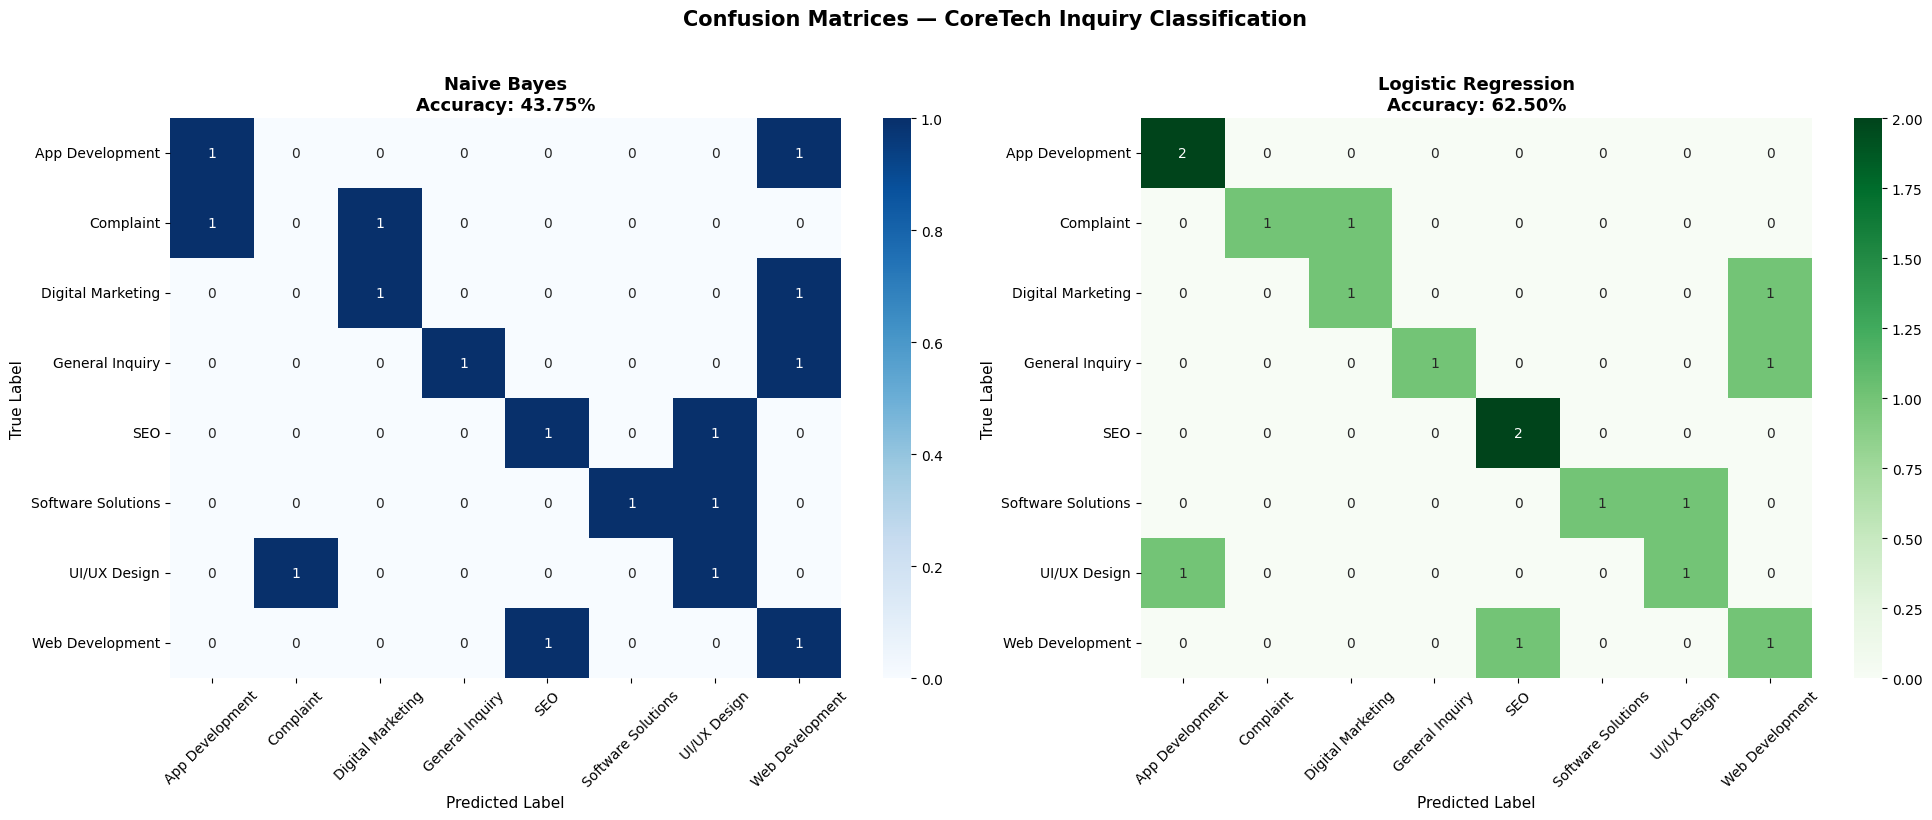

📊 Saved as confusion_matrices.png


In [11]:
labels = sorted(df['category'].unique())

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Naive Bayes\nAccuracy: {nb_accuracy*100:.2f}%', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title(f'Logistic Regression\nAccuracy: {lr_accuracy*100:.2f}%', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices — CoreTech Inquiry Classification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved as confusion_matrices.png')

## 📈 Step 9: Model Comparison

=== MODEL COMPARISON TABLE ===
              Model  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
        Naive Bayes     43.75              51.04           43.75             44.58
Logistic Regression     62.50              70.83           62.50             62.50


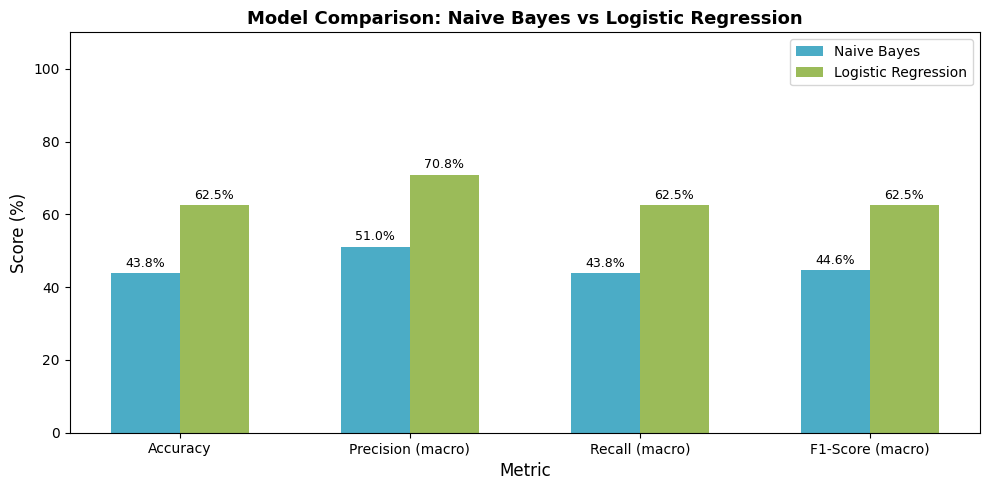

📊 Saved as model_comparison.png


In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics = {
    'Model': ['Naive Bayes', 'Logistic Regression'],
    'Accuracy': [
        round(accuracy_score(y_test, y_pred_nb) * 100, 2),
        round(accuracy_score(y_test, y_pred_lr) * 100, 2)
    ],
    'Precision (macro)': [
        round(precision_score(y_test, y_pred_nb, average='macro', zero_division=0) * 100, 2),
        round(precision_score(y_test, y_pred_lr, average='macro', zero_division=0) * 100, 2)
    ],
    'Recall (macro)': [
        round(recall_score(y_test, y_pred_nb, average='macro', zero_division=0) * 100, 2),
        round(recall_score(y_test, y_pred_lr, average='macro', zero_division=0) * 100, 2)
    ],
    'F1-Score (macro)': [
        round(f1_score(y_test, y_pred_nb, average='macro', zero_division=0) * 100, 2),
        round(f1_score(y_test, y_pred_lr, average='macro', zero_division=0) * 100, 2)
    ]
}

comparison_df = pd.DataFrame(metrics)
print('=== MODEL COMPARISON TABLE ===')
print(comparison_df.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))
metric_cols = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']
x = np.arange(len(metric_cols))
width = 0.3

bars1 = ax.bar(x - width/2, comparison_df.iloc[0][metric_cols], width, label='Naive Bayes', color='#4BACC6')
bars2 = ax.bar(x + width/2, comparison_df.iloc[1][metric_cols], width, label='Logistic Regression', color='#9BBB59')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Model Comparison: Naive Bayes vs Logistic Regression', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 110)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Saved as model_comparison.png')

## 🔮 Step 10: Test with New Messages

In [13]:
def predict_category(message, model, vectorizer):
    """Predict category for a new client message."""
    vec = vectorizer.transform([message])
    prediction = model.predict(vec)[0]
    probabilities = model.predict_proba(vec)[0]
    confidence = max(probabilities) * 100
    return prediction, confidence

test_messages = [
    "I want a Shopify store for my clothing business.",
    "Your project manager never replies to our emails.",
    "We want to rank #1 on Google for our target keywords.",
    "Can you build a Flutter app for iOS and Android?",
    "What are your payment terms and project timelines?",
    "Help us run Instagram ads to grow our brand.",
]

print('=' * 65)
print('       🔮 PREDICTIONS ON NEW MESSAGES')
print('=' * 65)

for msg in test_messages:
    nb_pred,  nb_conf  = predict_category(msg, nb_model,  tfidf)
    lr_pred,  lr_conf  = predict_category(msg, lr_model,  tfidf)
    print(f'\n📩 Message: "{msg}"')
    print(f'   Naive Bayes         → {nb_pred:<22} (confidence: {nb_conf:.1f}%)')
    print(f'   Logistic Regression → {lr_pred:<22} (confidence: {lr_conf:.1f}%)')

       🔮 PREDICTIONS ON NEW MESSAGES

📩 Message: "I want a Shopify store for my clothing business."
   Naive Bayes         → Digital Marketing      (confidence: 22.3%)
   Logistic Regression → Digital Marketing      (confidence: 17.3%)

📩 Message: "Your project manager never replies to our emails."
   Naive Bayes         → Complaint              (confidence: 23.2%)
   Logistic Regression → Complaint              (confidence: 17.9%)

📩 Message: "We want to rank #1 on Google for our target keywords."
   Naive Bayes         → SEO                    (confidence: 22.8%)
   Logistic Regression → SEO                    (confidence: 17.3%)

📩 Message: "Can you build a Flutter app for iOS and Android?"
   Naive Bayes         → App Development        (confidence: 34.7%)
   Logistic Regression → App Development        (confidence: 25.4%)

📩 Message: "What are your payment terms and project timelines?"
   Naive Bayes         → General Inquiry        (confidence: 31.1%)
   Logistic Regression → Gen

## 💾 Step 11: Save the Dataset as CSV

In [14]:
# Save dataset (drop helper columns first)
df_save = df[['message', 'category']].copy()
df_save.to_csv('coretech_client_inquiries.csv', index=False)
print('✅ Dataset saved as: coretech_client_inquiries.csv')
print(f'   Total records: {len(df_save)}')

# Download in Colab
# from google.colab import files
# files.download('coretech_client_inquiries.csv')

✅ Dataset saved as: coretech_client_inquiries.csv
   Total records: 80


## ✅ Summary

| Step | Task | Status |
|------|------|--------|
| 1 | Libraries imported | ✅ |
| 2 | Dataset loaded (80 records, 8 categories) | ✅ |
| 3 | EDA & visualizations | ✅ |
| 4 | Train-test split (80/20, stratified) | ✅ |
| 5 | TF-IDF vectorization (unigrams + bigrams) | ✅ |
| 6 | Naive Bayes trained & evaluated | ✅ |
| 7 | Logistic Regression trained & evaluated | ✅ |
| 8 | Confusion matrices plotted | ✅ |
| 9 | Model comparison | ✅ |
| 10 | Live predictions on new messages | ✅ |